# COE 311K Midterm Project

## Introduction

This project analyzes U.S. GDP growth using the selected quarterly data provided in the handout. The goal is to compare a few different methods and see how well they fit the data

The x-values were defined as consecutive integer indices from 1 to 20. The y-values are the GDP growth rates corresponding to those selected quarters.

Three methods were used in this project: least squares linear regression, a degree-4 polynomial fit using a Vandermonde matrix, and natural cubic spline interpolation. Each method was implemented using the approach shown in the slides and then compared based on fit and behavior.

The results are evaluated using plots and residuals, and the differences between the methods are discussed to determine which approach best represents the data.

In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [37]:
quarter_labels = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1",
    "2014 Q3", "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4",
    "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2",
    "2020 Q3", "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"
]

y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
], dtype=float)

x = np.arange(1, len(y) + 1, dtype=float)

print("quarter labels =", quarter_labels)
print("x =", x)
print("y =", y)


quarter labels = ['2010 Q1', '2011 Q1', '2012 Q1', '2013 Q1', '2014 Q1', '2014 Q3', '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q4', '2017 Q1', '2018 Q1', '2019 Q1', '2020 Q1', '2020 Q2', '2020 Q3', '2021 Q1', '2022 Q1', '2023 Q2', '2023 Q4']
x = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
y = [  1.7   0.1   2.3   2.7   1.7   5.    3.    1.5   3.5   1.8   1.3   2.5
   3.1  -5.1 -28.1  33.8   6.3  -1.6   2.4   3.3]


In [45]:
def least_squares_line(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x**2)
    sum_xy = np.sum(x * y)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - (sum_x)**2)
    c = (sum_y - m * sum_x) / n
    return m, c


def create_vandermonde_matrix(x, degree):
    V = np.zeros((len(x), degree + 1))
    for i in range(len(x)):
        for j in range(degree + 1):
            V[i, j] = x[i]**j
    return V


def polynomial_fit(x, y, degree):
    V = create_vandermonde_matrix(x, degree)

    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)

    return coefficients


def evaluate_polynomial(coefficients, x_values):
    V = create_vandermonde_matrix(np.array(x_values, dtype=float), len(coefficients) - 1)
    return V @ coefficients


def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    n = len(b)

    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x


def natural_spline_second_derivatives(x, y):
    A, B, C, D = setup_tridiagonal_matrix(x, y)

    M_interior = thomas_algorithm(A[1:].copy(), B.copy(), C[:-1].copy(), D.copy())

    M = np.zeros(len(x))
    M[1:-1] = M_interior
    return M


def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    h = np.diff(x_data)

    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2)

    hi = h[i]
    dx_left = x_query - x_data[i]
    dx_right = x_data[i + 1] - x_query

    S = (
        (M[i] / (6 * hi)) * dx_right**3 +
        (M[i + 1] / (6 * hi)) * dx_left**3 +
        (y_data[i] / hi - M[i] * hi / 6) * dx_right +
        (y_data[i + 1] / hi - M[i + 1] * hi / 6) * dx_left
    )

    return S


## Part A - Cubic spline interpolation


In [49]:
A, B, C, D = setup_tridiagonal_matrix(x, y)
M = natural_spline_second_derivatives(x, y)

print("Number of data points:", len(x))
print("Number of spline intervals:", len(x) - 1)
print("Number of interior unknown second derivatives:", len(x) - 2)
print("Natural boundary conditions: M0 = 0 and Mn-1 = 0")
print("Subdiagonal A =", A)
print("Main diagonal B =", B)
print("Superdiagonal C =", C)
print("Right-hand side D =", D)
print("Second derivatives M =", M)


Number of data points: 20
Number of spline intervals: 19
Number of interior unknown second derivatives: 18
Natural boundary conditions: M0 = 0 and Mn-1 = 0
Subdiagonal A = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Main diagonal B = [4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
Superdiagonal C = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Right-hand side D = [  22.8  -10.8   -8.4   25.8  -31.8    3.    21.   -22.2    7.2   10.2
   -3.6  -52.8  -88.8  509.4 -536.4  117.6   71.4  -18.6]
Second derivatives M = [   0.            6.54772205   -3.3908882    -3.78416926   10.12756524
  -10.92609171    1.7768016     6.81888531   -8.05234285    3.19048608
    2.49039852   -2.95208014    5.71792206  -72.71960811  196.36051038
 -203.3224334    80.52922323   -1.19445953   -4.35138512    0.        ]


For a natural cubic spline, the continuity conditions at each interior knot are:

- the spline values match at the knot (**C0 continuity**)
- the first derivatives match (**C1 continuity**)
- the second derivatives match (**C2 continuity**)

The natural boundary conditions are \(M_0 = 0\) and \(M_{n-1} = 0\).


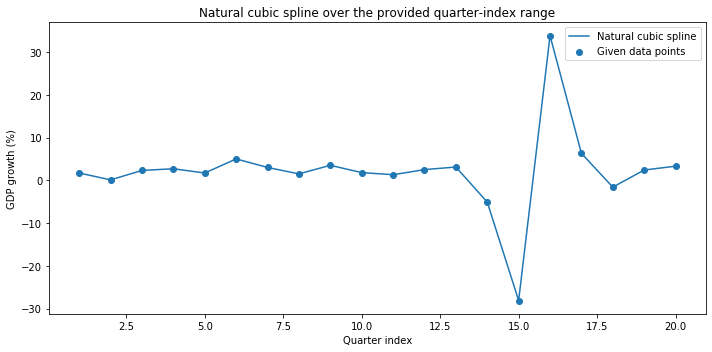

In [50]:
full_quarter_indices = np.arange(1, len(x) + 1)
spline_full = np.array([evaluate_spline(x, y, M, q) for q in full_quarter_indices])

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Given data points")
plt.plot(full_quarter_indices, spline_full, label="Natural cubic spline")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Natural cubic spline over the provided quarter-index range")
plt.legend()
plt.tight_layout()
plt.show()


The spline is smooth in the sense that it has continuous value, first derivative, and second derivative at the interior knots. Visually, it follows the overall pattern well, but it also reacts strongly near the extreme 2020 values because interpolation forces the curve to hit those exact points.


In [51]:
spline_at_knots = np.array([evaluate_spline(x, y, M, xi) for xi in x])
print("Maximum interpolation error at the given knots:", np.max(np.abs(spline_at_knots - y)))


Maximum interpolation error at the given knots: 7.105427357601002e-15


The spline passes exactly through the provided points, including 2020 Q2 = -28.1 and 2020 Q3 = 33.8.

### Runge phenomenon / outlier discussion
Runge phenomenon is the oscillation problem that can happen when one high-degree global polynomial is forced to match data exactly, especially near the ends of an interval. A spline reduces that problem because it is piecewise and local instead of one global polynomial. Even so, exact interpolation still has a trade-off: if the data contains a very large outlier, the spline must go through it exactly, so the curve can become steep or distorted nearby.

For this dataset, a smoothing spline or weighted least squares model could be preferable if the goal is to reduce the effect of the COVID shock and recover a more stable economic trend. A natural spline is still a good interpolation tool, but exact interpolation is not always the best choice when a point is extreme.


## Part B - Polynomial and least squares comparison


In [52]:
degree = 4
coefficients = polynomial_fit(x, y, degree)
y_poly = evaluate_polynomial(coefficients, x)
poly_residuals = y - y_poly
poly_rmse = np.sqrt(np.mean(poly_residuals**2))
cond_v = np.linalg.cond(create_vandermonde_matrix(x, degree))

print("Degree-4 coefficients =", coefficients)
print("RMSE =", poly_rmse)
print("Condition number of V =", cond_v)


Degree-4 coefficients = [-4.13737100e+00  4.44241917e+00 -8.23719896e-01  5.44711952e-02
 -1.17213791e-03]
RMSE = 9.965326786519531
Condition number of V = 482958.7228348024


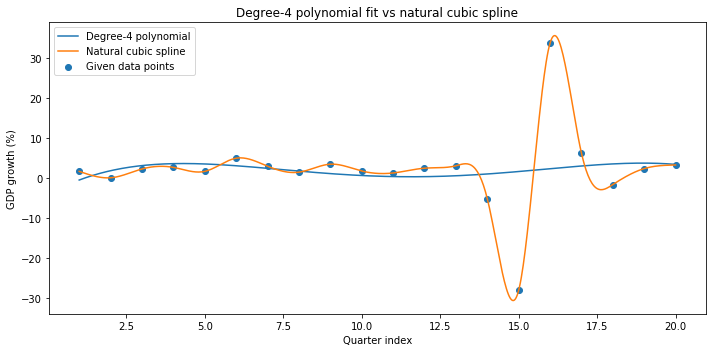

In [53]:
x_plot = np.linspace(1, len(x), 600)
y_poly_plot = evaluate_polynomial(coefficients, x_plot)
y_spline_plot = np.array([evaluate_spline(x, y, M, value) for value in x_plot])

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Given data points")
plt.plot(x_plot, y_poly_plot, label="Degree-4 polynomial")
plt.plot(x_plot, y_spline_plot, label="Natural cubic spline")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Degree-4 polynomial fit vs natural cubic spline")
plt.legend()
plt.tight_layout()
plt.show()


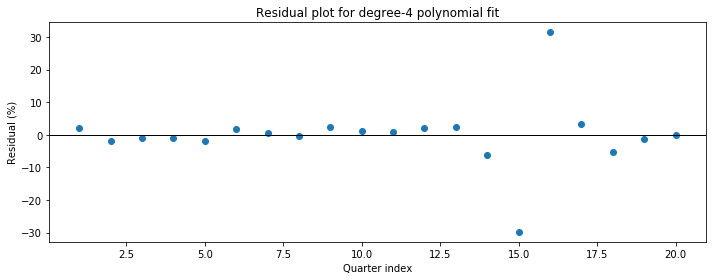

In [54]:
plt.figure(figsize=(10, 4))
plt.axhline(0, color="black", linewidth=1)
plt.scatter(x, poly_residuals)
plt.xlabel("Quarter index")
plt.ylabel("Residual (%)")
plt.title("Residual plot for degree-4 polynomial fit")
plt.tight_layout()
plt.show()


The degree-4 polynomial captures the broad trend, but it does not reproduce the specific points as closely as the spline. That makes sense because the polynomial is an approximation method, while the spline is an interpolation method. The spline is better when I want the curve to pass through the known values. The polynomial is better when I want a smoother global trend and I do not need exact agreement at every point.


In [55]:
covid_labels = {"2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1"}
covid_mask = np.array([label not in covid_labels for label in quarter_labels])

x_no_covid = x[covid_mask]
y_no_covid = y[covid_mask]

m, c = least_squares_line(x_no_covid, y_no_covid)
y_line = m * x_no_covid + c
line_residuals = y_no_covid - y_line
line_rmse = np.sqrt(np.mean(line_residuals**2))

print("Slope =", m)
print("Intercept =", c)
print("RMSE =", line_rmse)


Slope = -0.0173364485981308
Intercept = 2.3041121495327097
RMSE = 1.4400212550352411


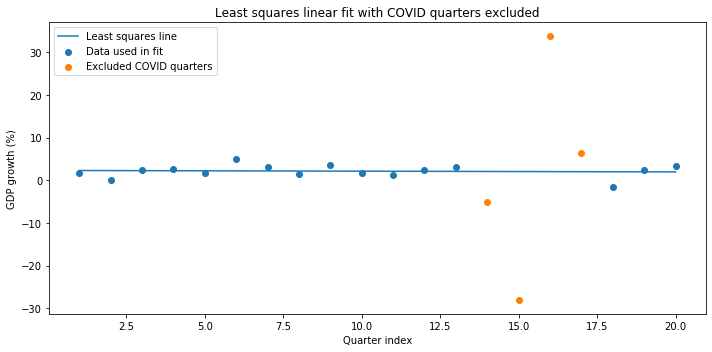

In [56]:
x_line_plot = np.linspace(np.min(x_no_covid), np.max(x_no_covid), 300)

plt.figure(figsize=(10, 5))
plt.scatter(x_no_covid, y_no_covid, label="Data used in fit")
plt.scatter(x[~covid_mask], y[~covid_mask], label="Excluded COVID quarters")
plt.plot(x_line_plot, m * x_line_plot + c, label="Least squares line")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Least squares linear fit with COVID quarters excluded")
plt.legend()
plt.tight_layout()
plt.show()


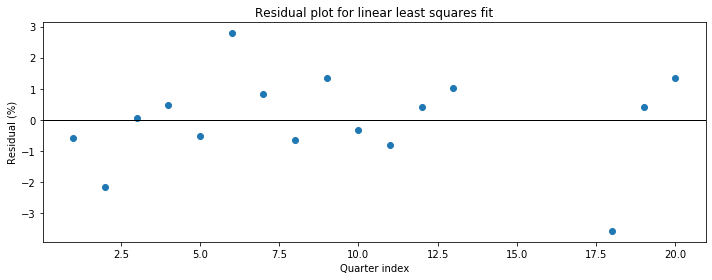

In [57]:
plt.figure(figsize=(10, 4))
plt.axhline(0, color="black", linewidth=1)
plt.scatter(x_no_covid, line_residuals)
plt.xlabel("Quarter index")
plt.ylabel("Residual (%)")
plt.title("Residual plot for linear least squares fit")
plt.tight_layout()
plt.show()


The slope is slightly negative, about -0.0173. That means the fitted line suggests a small downward trend across the non-COVID data. A linear trend does not fully capture the economics here because GDP growth clearly moves up and down over time, so using one line assumes the overall movement is approximately linear and that the remaining variation is just noise around it. That is a strong assumption for this dataset.


## Part C - Method justification

For a policymaker who needs interpolation between two known quarters, I would recommend the **cubic spline** instead of polynomial fitting.

My reasons are that the spline is smooth, matches the data exactly, is local(meaning unusual points do less damage to the curve), and behaves better between nearby knots. 

The polynomial fit is useful for trend estimation, but for interpolation it is less reliable because it does not have to hit the known values and it is more sensitive to the global shape of the dataset.


## Part C addendum - Big O notation

Big O notation describes how the amount of work grows as the problem size gets larger.

For these methods:

- **Least squares line:** computing the sums is **O(n)**
- **Degree-4 polynomial fit:** building the Vandermonde matrix is **O(n d)** and forming/solving the normal equations is about **O(n d^2 + d^3)**; with fixed degree 4, this is effectively **O(n)**
- **Natural cubic spline:** building the tridiagonal system is **O(n)** and Thomas's algorithm is also **O(n)**

So Big O does **not** change my recommendation. For this project, all three methods are cheap at this data size. The recommendation should depend more on what the method is supposed to do. For interpolation between known quarters, spline is still the best choice because of its smooth local behavior and exact matching at the knots.


## Conclusion

The spline worked best for interpolation because it passed through all given points and stayed smooth between them. The degree-4 polynomial was better for a broad trend than for exact point matching. The linear least squares model was the simplest model, but it was too limited to describe all of the movement in GDP growth. This project made the trade-off clear: simple models are easy to interpret, but splines are better when the main goal is accurate interpolation.


### *AI Used to help with excluding COVID Values, polishing up descriptions for clarity, getting line to pass 28.1, some terminology, ensuring function outputs are correct, and revising finished .ipynb file. *